# Lab 3: K-Means Clustering with Real Sales Data

## What is this lab about?

In this lab, you will learn how to group customers based on their purchase amounts. This is called **Customer Segmentation** and is used by companies like Amazon, Netflix, and Spotify.

## What you will learn:
- How to create a dataset in Python
- How to explore and understand your data
- How to apply K-Means clustering
- How to visualize the results
- How to interpret clusters for business decisions

---

**Instructions:** Run each cell one by one by clicking the Play button or pressing Shift+Enter

---
## Step 1: Import the Libraries

First, we need to load the tools (libraries) we will use:

- **pandas** - helps us work with data in table format
- **sklearn** - provides machine learning algorithms
- **matplotlib** - helps us create charts and graphs

In [55]:
# Import pandas for data handling
import pandas as pd

In [56]:
# Import KMeans from sklearn
from sklearn.cluster import KMeans

In [57]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

In [58]:
# Print a message to confirm all libraries are loaded
print("All libraries loaded successfully!")
print("You are ready to start the lab.")

All libraries loaded successfully!
You are ready to start the lab.


---
## Step 2: Create the Sales Dataset

Instead of loading data from a file, we will create it directly in Python.

This is Amazon sales data with 3 columns:
- **OrderID** - a unique number for each order
- **Amount** - how much money the customer spent (in dollars)
- **Category** - what type of product they bought

In [59]:
# Create order IDs from 1 to 50
order_ids = list(range(1, 51))

# Print to verify
print("Order IDs created:")
print(order_ids)

Order IDs created:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


In [60]:
# Create purchase amounts
# These represent different spending levels
amounts = [
    100, 200, 250, 500, 600,   # Orders 1-5
    100, 200, 250, 500, 600,   # Orders 6-10
    100, 200, 250, 500, 600,   # Orders 11-15
    100, 200, 250, 500, 600,   # Orders 16-20
    100, 200, 250, 500, 600,   # Orders 21-25
    100, 200, 250, 500, 600,   # Orders 26-30
    100, 200, 250, 500, 600,   # Orders 31-35
    100, 200, 250, 500, 600,   # Orders 36-40
    100, 200, 250, 500, 600,   # Orders 41-45
    100, 200, 250, 500, 600    # Orders 46-50
]

print("Purchase amounts created:")
print(amounts)

Purchase amounts created:
[100, 200, 250, 500, 600, 100, 200, 250, 500, 600, 100, 200, 250, 500, 600, 100, 200, 250, 500, 600, 100, 200, 250, 500, 600, 100, 200, 250, 500, 600, 100, 200, 250, 500, 600, 100, 200, 250, 500, 600, 100, 200, 250, 500, 600, 100, 200, 250, 500, 600]


In [61]:
# Create product categories
# We repeat the pattern 10 times to get 50 items
categories = ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing'] * 10

print("Categories created:")
print(categories)

Categories created:
['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing']


In [62]:
# Put all data together in a dictionary
data = {
    'OrderID': order_ids,
    'Amount': amounts,
    'Category': categories
}

print("Data dictionary created with keys:")
print(data.keys())

Data dictionary created with keys:
dict_keys(['OrderID', 'Amount', 'Category'])


In [63]:
# Convert the dictionary to a DataFrame (table)
df = pd.DataFrame(data)

print("DataFrame created successfully!")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")

DataFrame created successfully!
Shape: 50 rows and 3 columns


In [64]:
# Look at the first 10 rows of our data
print("First 10 rows of the dataset:")
print("=" * 40)
df.head(10)

First 10 rows of the dataset:


,OrderID,Amount,Category
0,1,100,Electronics
1,2,200,Clothing
2,3,250,Electronics
3,4,500,Home
4,5,600,Clothing
5,6,100,Electronics
6,7,200,Clothing
7,8,250,Electronics
8,9,500,Home
9,10,600,Clothing


---
## Step 3: Explore the Data

Before we start clustering, we need to understand our data.

**Questions to answer:**
- How many orders do we have?
- What is the smallest and largest purchase?
- What is the average purchase amount?
- How many orders are in each category?

In [65]:
# Count total number of orders
total_orders = len(df)

print(f"Total number of orders: {total_orders}")

Total number of orders: 50


In [66]:
# Find the smallest order amount
min_amount = df['Amount'].min()

print(f"Smallest order amount: ${min_amount}")

Smallest order amount: $100


In [67]:
# Find the largest order amount
max_amount = df['Amount'].max()

print(f"Largest order amount: ${max_amount}")

Largest order amount: $600


In [68]:
# Calculate the average (mean) order amount
avg_amount = df['Amount'].mean()

print(f"Average order amount: ${avg_amount:.2f}")

Average order amount: $330.00


In [69]:
# Count orders in each category
category_counts = df['Category'].value_counts()

print("Number of orders by category:")
print(category_counts)

Number of orders by category:
Category
Electronics    20
Clothing       20
Home           10
Name: count, dtype: int64


In [70]:
# Get a quick summary of all numeric columns
print("Statistical summary of the data:")
df.describe()

Statistical summary of the data:


,OrderID,Amount
count,50.00000,50.000000
mean,25.50000,330.000000
std,14.57738,190.595201
min,1.00000,100.000000
25%,13.25000,200.000000
50%,25.50000,250.000000
75%,37.75000,500.000000
max,50.00000,600.000000


---
## Step 4: Prepare the Data for Clustering

K-Means works with numbers only. We will use the **Amount** column to group orders.

**Why Amount?** Because it tells us how much each customer spends. This helps us find:
- Low spenders
- Medium spenders  
- High spenders

In [71]:
# Select the Amount column for clustering
# We use double brackets [[]] to keep it as a DataFrame
X = df[['Amount']]

print("Feature selected for clustering: Amount")
print(f"Shape of X: {X.shape}")

Feature selected for clustering: Amount
Shape of X: (50, 1)


In [72]:
# Look at the first 5 values
print("First 5 values of X:")
X.head()

First 5 values of X:


,Amount
0,100
1,200
2,250
3,500
4,600


---
## Step 5: Create the K-Means Model

Now we create the K-Means model. We need to decide:

- **n_clusters = 3** → We want 3 groups (low, medium, high spenders)
- **random_state = 42** → This makes sure we get the same result every time
- **n_init = 10** → The algorithm runs 10 times and picks the best result

In [73]:
# Create the K-Means model
# n_clusters=3 means we want 3 groups (low, medium, high spenders)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

print("K-Means model created!")
print(f"Number of clusters: 3")

K-Means model created!
Number of clusters: 3


---
## Step 6: Train the Model and Predict Clusters

Now we tell the model to:
1. Learn from the data (fit)
2. Assign each order to a cluster (predict)

We do both steps at once with `fit_predict()`

In [74]:
# Fit the model and predict clusters
cluster_labels = kmeans.fit_predict(X)

print("Model trained successfully!")
print(f"Number of labels created: {len(cluster_labels)}")

Model trained successfully!
Number of labels created: 50


c:\Users\iqras\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [75]:
# Look at the cluster labels
# Each number (0, 1, or 2) represents a different cluster
print("Cluster labels for first 20 orders:")
print(cluster_labels[:20])

Cluster labels for first 20 orders:
[1 2 2 0 0 1 2 2 0 0 1 2 2 0 0 1 2 2 0 0]


In [76]:
# Add cluster labels to our DataFrame
df['Cluster'] = cluster_labels

print("Cluster column added to DataFrame!")

Cluster column added to DataFrame!


In [77]:
# Look at the updated DataFrame
print("DataFrame with cluster labels:")
df.head(10)

DataFrame with cluster labels:


,OrderID,Amount,Category,Cluster
0,1,100,Electronics,1
1,2,200,Clothing,2
2,3,250,Electronics,2
3,4,500,Home,0
4,5,600,Clothing,0
5,6,100,Electronics,1
6,7,200,Clothing,2
7,8,250,Electronics,2
8,9,500,Home,0
9,10,600,Clothing,0


---
## Step 7: Understand the Cluster Centers

Each cluster has a **center** (also called centroid). This is the average amount for that cluster.

The centers tell us what each cluster represents.

In [78]:
# Get the cluster centers
centers = kmeans.cluster_centers_

print("Cluster Centers (Average Amount in each cluster):")
print("=" * 45)

Cluster Centers (Average Amount in each cluster):


In [79]:
# Print each cluster center with its meaning
for i, center in enumerate(centers):
    amount = center[0]
    print(f"Cluster {i}: Average spending = ${amount:.2f}")

Cluster 0: Average spending = $550.00
Cluster 1: Average spending = $100.00
Cluster 2: Average spending = $225.00


---
## Step 8: Count Orders in Each Cluster

Let's see how many orders fall into each cluster.

In [80]:
# Count orders in each cluster
cluster_counts = df['Cluster'].value_counts().sort_index()

print("Number of orders in each cluster:")
print("=" * 35)

Number of orders in each cluster:


In [81]:
# Print the counts
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} orders")

Cluster 0: 20 orders
Cluster 1: 10 orders
Cluster 2: 20 orders


---
## Step 9: Look at Examples from Each Cluster

Let's see some actual orders from each cluster to understand them better.

In [82]:
# Show examples from Cluster 0
print("\n" + "=" * 50)
print("CLUSTER 0 - Sample Orders:")
print("=" * 50)

cluster_0 = df[df['Cluster'] == 0]
print(cluster_0[['OrderID', 'Amount', 'Category']].head(5).to_string(index=False))


CLUSTER 0 - Sample Orders:
 OrderID  Amount Category
       4     500     Home
       5     600 Clothing
       9     500     Home
      10     600 Clothing
      14     500     Home


In [83]:
# Show examples from Cluster 1
print("\n" + "=" * 50)
print("CLUSTER 1 - Sample Orders:")
print("=" * 50)

cluster_1 = df[df['Cluster'] == 1]
print(cluster_1[['OrderID', 'Amount', 'Category']].head(5).to_string(index=False))


CLUSTER 1 - Sample Orders:
 OrderID  Amount    Category
       1     100 Electronics
       6     100 Electronics
      11     100 Electronics
      16     100 Electronics
      21     100 Electronics


In [84]:
# Show examples from Cluster 2
print("\n" + "=" * 50)
print("CLUSTER 2 - Sample Orders:")
print("=" * 50)

cluster_2 = df[df['Cluster'] == 2]
print(cluster_2[['OrderID', 'Amount', 'Category']].head(5).to_string(index=False))


CLUSTER 2 - Sample Orders:
 OrderID  Amount    Category
       2     200    Clothing
       3     250 Electronics
       7     200    Clothing
       8     250 Electronics
      12     200    Clothing


---
## Step 10: Create a Basic Scatter Plot

Let's visualize our clusters with a simple chart first.

In [85]:
# Create a figure (the blank canvas)
plt.figure(figsize=(10, 6))

print("Figure created with size 10x6 inches")

Figure created with size 10x6 inches


<Figure size 1000x600 with 0 Axes>

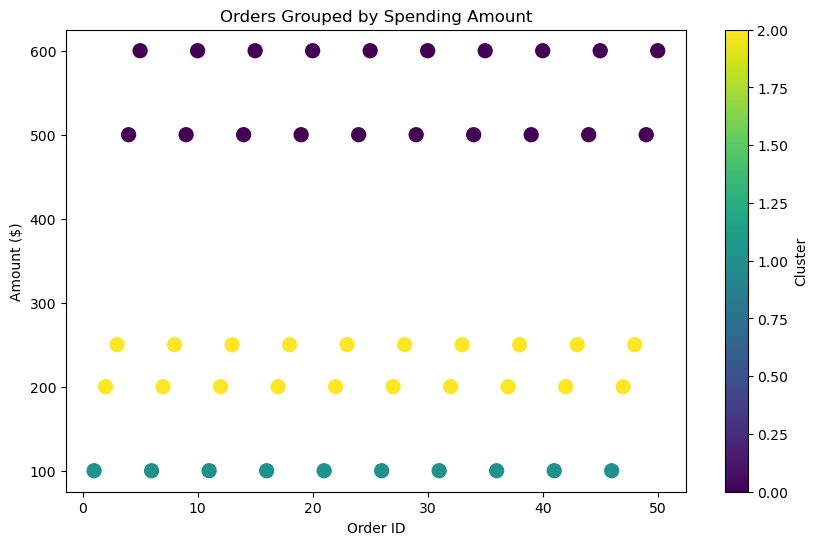

Basic scatter plot created!


In [86]:
# Create a simple scatter plot
plt.figure(figsize=(10, 6))

# Plot all points, colored by cluster
scatter = plt.scatter(
    df['OrderID'],      # X-axis: Order ID
    df['Amount'],       # Y-axis: Amount
    c=df['Cluster'],    # Color by cluster
    cmap='viridis',     # Color scheme
    s=100               # Size of points
)

# Add labels
plt.xlabel('Order ID')
plt.ylabel('Amount ($)')
plt.title('Orders Grouped by Spending Amount')
plt.colorbar(scatter, label='Cluster')

plt.show()
print("Basic scatter plot created!")

---
## Step 11: Create a Better Visualization

Now let's make a more professional chart with custom colors and labels.

In [87]:
# Define custom colors for each cluster
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

print("Colors defined:")
print("Cluster 0: Red (#FF6B6B)")
print("Cluster 1: Teal (#4ECDC4)")
print("Cluster 2: Blue (#45B7D1)")

Colors defined:
Cluster 0: Red (#FF6B6B)
Cluster 1: Teal (#4ECDC4)
Cluster 2: Blue (#45B7D1)


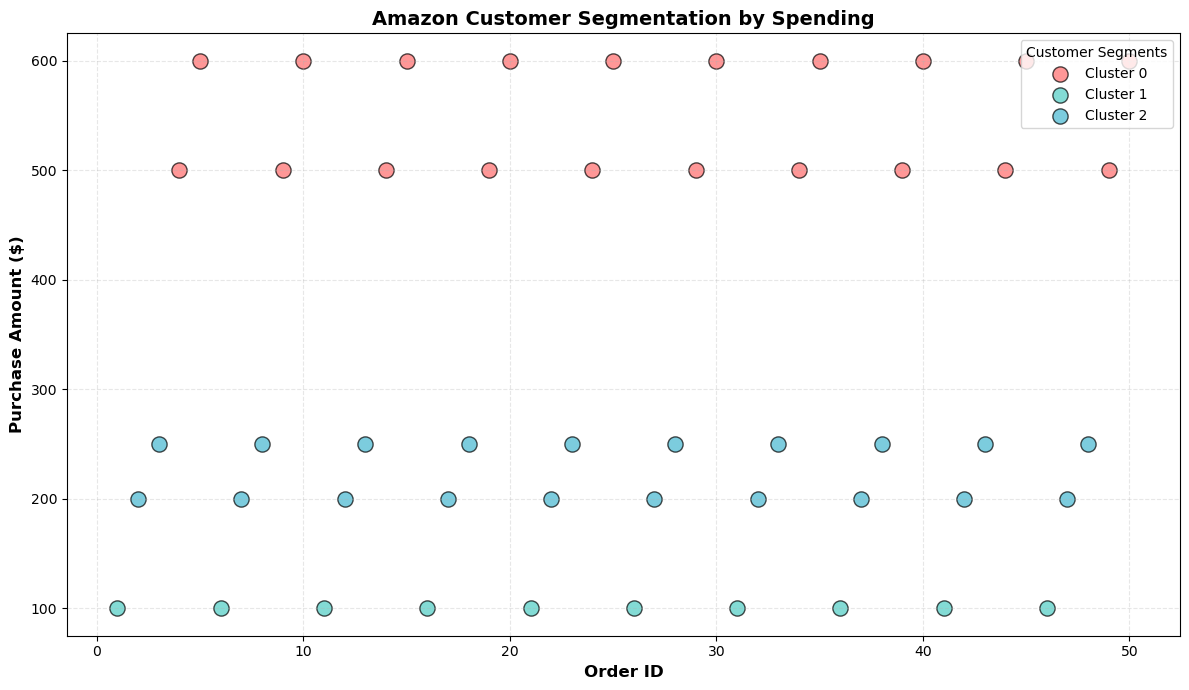

Professional chart created!


In [88]:
# Create the professional chart
plt.figure(figsize=(12, 7))

# Plot each cluster separately with custom colors
for cluster_num in sorted(df['Cluster'].unique()):
    # Get data for this cluster
    cluster_data = df[df['Cluster'] == cluster_num]
    
    # Plot the points
    plt.scatter(
        cluster_data['OrderID'], 
        cluster_data['Amount'],
        c=colors[cluster_num],
        label=f'Cluster {cluster_num}',
        s=120,
        alpha=0.7,
        edgecolors='black',
        linewidth=1
    )

# Add labels and title
plt.xlabel('Order ID', fontsize=12, fontweight='bold')
plt.ylabel('Purchase Amount ($)', fontsize=12, fontweight='bold')
plt.title('Amazon Customer Segmentation by Spending', fontsize=14, fontweight='bold')

# Add legend and grid
plt.legend(title='Customer Segments', loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')

# Show the chart
plt.tight_layout()
plt.show()

print("Professional chart created!")

---
## Step 12: Create a Bar Chart of Cluster Sizes

Let's also see how many customers are in each cluster using a bar chart.

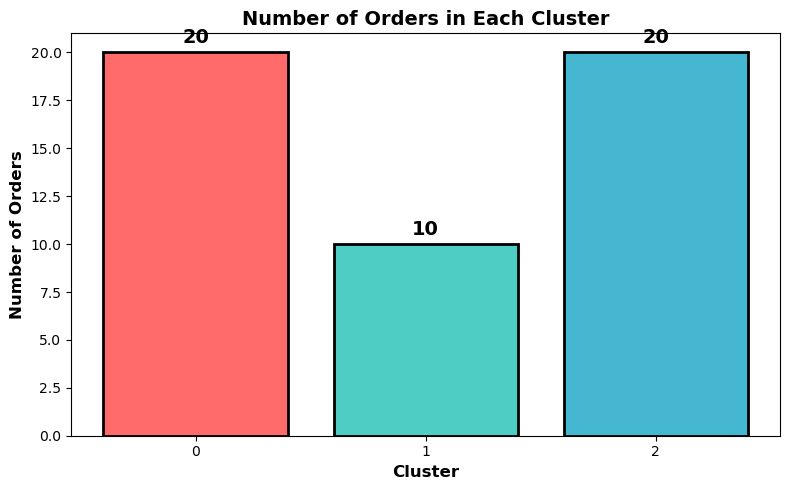

Bar chart created!


In [89]:
# Create a bar chart
plt.figure(figsize=(8, 5))

# Get cluster counts
counts = df['Cluster'].value_counts().sort_index()

# Create bar chart
bars = plt.bar(
    counts.index, 
    counts.values,
    color=colors,
    edgecolor='black',
    linewidth=2
)

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(count),
        ha='center',
        fontsize=14,
        fontweight='bold'
    )

plt.xlabel('Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Number of Orders', fontsize=12, fontweight='bold')
plt.title('Number of Orders in Each Cluster', fontsize=14, fontweight='bold')
plt.xticks([0, 1, 2])

plt.tight_layout()
plt.show()

print("Bar chart created!")

---
## Step 13: Give Business Names to Each Cluster

Now let's interpret our clusters and give them meaningful business names.

This is what companies like Amazon do - they use clusters to understand their customers and create marketing strategies.

In [90]:
# Create a summary for each cluster
print("\n" + "=" * 70)
print("CUSTOMER SEGMENTATION REPORT")
print("=" * 70)


CUSTOMER SEGMENTATION REPORT


In [91]:
# Analyze each cluster
for cluster_num in sorted(df['Cluster'].unique()):
    # Get data for this cluster
    cluster_data = df[df['Cluster'] == cluster_num]
    
    # Calculate statistics
    avg_amount = cluster_data['Amount'].mean()
    count = len(cluster_data)
    
    # Assign business name based on spending
    if avg_amount <= 150:
        customer_type = "BUDGET CUSTOMERS"
        emoji = "💰"
        suggestion = "Offer discounts and deals to encourage bigger purchases"
    elif avg_amount <= 250:
        customer_type = "REGULAR CUSTOMERS"
        emoji = "🛒"
        suggestion = "Send loyalty rewards and personalized recommendations"
    else:
        customer_type = "PREMIUM CUSTOMERS"
        emoji = "⭐"
        suggestion = "Offer VIP treatment, exclusive products, and priority service"
    
    # Print the summary
    print(f"\n{emoji} CLUSTER {cluster_num}: {customer_type}")
    print("-" * 50)
    print(f"   Number of orders: {count}")
    print(f"   Average spending: ${avg_amount:.2f}")
    print(f"   Marketing tip: {suggestion}")


⭐ CLUSTER 0: PREMIUM CUSTOMERS
--------------------------------------------------
   Number of orders: 20
   Average spending: $550.00
   Marketing tip: Offer VIP treatment, exclusive products, and priority service

💰 CLUSTER 1: BUDGET CUSTOMERS
--------------------------------------------------
   Number of orders: 10
   Average spending: $100.00
   Marketing tip: Offer discounts and deals to encourage bigger purchases

🛒 CLUSTER 2: REGULAR CUSTOMERS
--------------------------------------------------
   Number of orders: 20
   Average spending: $225.00
   Marketing tip: Send loyalty rewards and personalized recommendations


---
## Step 14: Export the Results

Let's save our clustered data so we can use it later.

In [92]:
# Show the final DataFrame
print("Final DataFrame with Clusters:")
print("=" * 50)
df.head(15)

Final DataFrame with Clusters:


,OrderID,Amount,Category,Cluster
0,1,100,Electronics,1
1,2,200,Clothing,2
2,3,250,Electronics,2
3,4,500,Home,0
4,5,600,Clothing,0
5,6,100,Electronics,1
6,7,200,Clothing,2
7,8,250,Electronics,2
8,9,500,Home,0
9,10,600,Clothing,0


In [93]:
# Save to a new CSV file (optional)
# Uncomment the line below if you want to save
# df.to_csv('clustered_orders.csv', index=False)

print("You can save the results by uncommenting the line above!")

You can save the results by uncommenting the line above!


---
## What Did We Learn?

### Key Takeaways:

1. **K-Means clustering** groups similar data points together without needing labels

2. **K** is the number of clusters (groups) you want to create

3. **Cluster centers** show the average value for each group

4. **Customer segmentation** helps businesses:
   - Understand their customers better
   - Create targeted marketing campaigns
   - Increase sales and customer satisfaction

5. **Real companies like Amazon, Netflix, and Spotify** use clustering every day!

---
## ✏️ Exercise 1: Change the Number of Clusters (`n_clusters = 4`)

**Goal:** Understand how the number of clusters affects segmentation.

In the original lab we used `n_clusters=3` (Budget / Regular / Premium).  
Now we set it to **4** and watch what happens.

**What to watch for:**
- Do the 5 distinct amounts (100, 200, 250, 500, 600) separate more cleanly?
- How do the cluster centers change?
- Does a 4th segment make business sense?


In [94]:
# Exercise 1 – Step A: Rebuild the dataset
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

order_ids  = list(range(1, 51))
amounts    = [100, 200, 250, 500, 600] * 10
categories = ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing'] * 10

df_ex1 = pd.DataFrame({'OrderID': order_ids, 'Amount': amounts, 'Category': categories})
X_ex1  = df_ex1[['Amount']]

print("Dataset ready. Shape:", df_ex1.shape)


Dataset ready. Shape: (50, 3)


In [95]:
# Exercise 1 – Step B: KMeans with n_clusters = 4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ex1['Cluster'] = kmeans_4.fit_predict(X_ex1)

print("Model trained with 4 clusters!")
print("Labels (first 20):", df_ex1["Cluster"].values[:20])


Model trained with 4 clusters!
Labels (first 20): [3 1 1 0 2 3 1 1 0 2 3 1 1 0 2 3 1 1 0 2]


c:\Users\iqras\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [96]:
# Exercise 1 – Step C: Print cluster centers
centers_4 = kmeans_4.cluster_centers_

print("Cluster Centers with 4 groups:")
print("=" * 40)
for i, c in enumerate(centers_4):
    print(f"  Cluster {i}: Average Amount = ${c[0]:.2f}")


Cluster Centers with 4 groups:
  Cluster 0: Average Amount = $500.00
  Cluster 1: Average Amount = $225.00
  Cluster 2: Average Amount = $600.00
  Cluster 3: Average Amount = $100.00


In [97]:
# Exercise 1 – Step D: Cluster size summary
counts_4 = df_ex1['Cluster'].value_counts().sort_index()

print("Orders per cluster (4 clusters):")
for cluster, count in counts_4.items():
    avg = df_ex1[df_ex1['Cluster'] == cluster]['Amount'].mean()
    print(f"  Cluster {cluster}: {count} orders | Avg = ${avg:.2f}")


Orders per cluster (4 clusters):
  Cluster 0: 10 orders | Avg = $500.00
  Cluster 1: 20 orders | Avg = $225.00
  Cluster 2: 10 orders | Avg = $600.00
  Cluster 3: 10 orders | Avg = $100.00


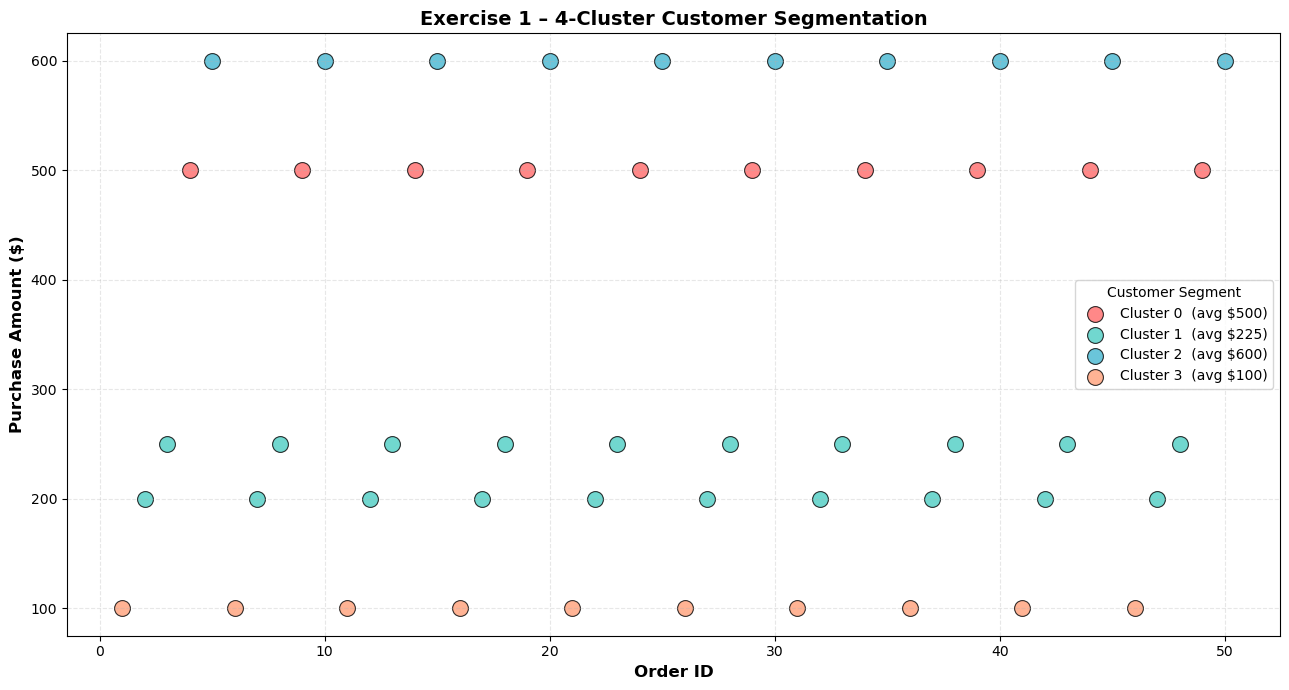

With 4 clusters each distinct spending level gets its own group!


In [98]:
# Exercise 1 – Step E: Scatter plot with 4 clusters
colors_4 = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

plt.figure(figsize=(13, 7))

for cluster_num in sorted(df_ex1['Cluster'].unique()):
    cdata = df_ex1[df_ex1['Cluster'] == cluster_num]
    avg   = cdata['Amount'].mean()
    plt.scatter(
        cdata['OrderID'], cdata['Amount'],
        c=colors_4[cluster_num],
        label=f'Cluster {cluster_num}  (avg ${avg:.0f})',
        s=130, alpha=0.8, edgecolors='black', linewidth=0.8
    )

plt.xlabel('Order ID', fontsize=12, fontweight='bold')
plt.ylabel('Purchase Amount ($)', fontsize=12, fontweight='bold')
plt.title('Exercise 1 – 4-Cluster Customer Segmentation', fontsize=14, fontweight='bold')
plt.legend(title='Customer Segment', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("With 4 clusters each distinct spending level gets its own group!")


### 🔍 Exercise 1 – What did we learn?

| Clusters | Groups | Detail Level |
|----------|--------|--------------|
| 3 | Low / Medium / High | Broad — \$500 & \$600 merged together |
| **4** | **Budget / Mid / High / Premium** | **Fine-grained — every spend level separated** |

> **Business insight:** Choosing the right `k` matters!  
> Too few clusters → lose detail. Too many → confusing segments.


---
## ✏️ Exercise 2: Add More Data — Including Very High Spenders (\$700–\$1,000)

**Goal:** See how new, extreme values shift the cluster centers.

We add 20 new orders with amounts of \$700–\$1,000.  
Watch how the cluster centers move compared to Exercise 1!


In [99]:
# Exercise 2 – Step A: Expand the dataset
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Original 50 orders
order_ids_orig  = list(range(1, 51))
amounts_orig    = [100, 200, 250, 500, 600] * 10
categories_orig = ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing'] * 10

# 20 new high-value orders (IDs 51-70)
extra_ids   = list(range(51, 71))
extra_amts  = [700, 750, 800, 850, 900, 950, 1000,
               700, 750, 800, 850, 900, 950, 1000,
               700, 800, 900, 1000, 750, 850]
extra_cats  = (['Electronics', 'Home', 'Electronics', 'Home',
                'Clothing', 'Electronics', 'Home'] * 3)[:20]

df_ex2 = pd.DataFrame({
    'OrderID':  order_ids_orig  + extra_ids,
    'Amount':   amounts_orig    + extra_amts,
    'Category': categories_orig + extra_cats
})

print(f"Expanded dataset: {len(df_ex2)} orders")
print(f"Amount range: ${df_ex2['Amount'].min()} – ${df_ex2['Amount'].max()}")
print(df_ex2['Amount'].describe().round(2))


Expanded dataset: 70 orders
Amount range: $100 – $1000
count      70.00
mean      477.14
std       289.14
min       100.00
25%       200.00
50%       500.00
75%       700.00
max      1000.00
Name: Amount, dtype: float64


In [100]:
# Exercise 2 – Step B: Cluster the expanded data (k=4)
X_ex2 = df_ex2[['Amount']]
kmeans_ex2 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ex2['Cluster'] = kmeans_ex2.fit_predict(X_ex2)

print("Cluster Centers (expanded dataset):")
print("=" * 45)
for i, c in enumerate(kmeans_ex2.cluster_centers_):
    count = (df_ex2['Cluster'] == i).sum()
    print(f"  Cluster {i}: avg ${c[0]:.2f}  ({count} orders)")


Cluster Centers (expanded dataset):
  Cluster 0: avg $183.33  (30 orders)
  Cluster 1: avg $750.00  (9 orders)
  Cluster 2: avg $550.00  (20 orders)
  Cluster 3: avg $922.73  (11 orders)


c:\Users\iqras\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


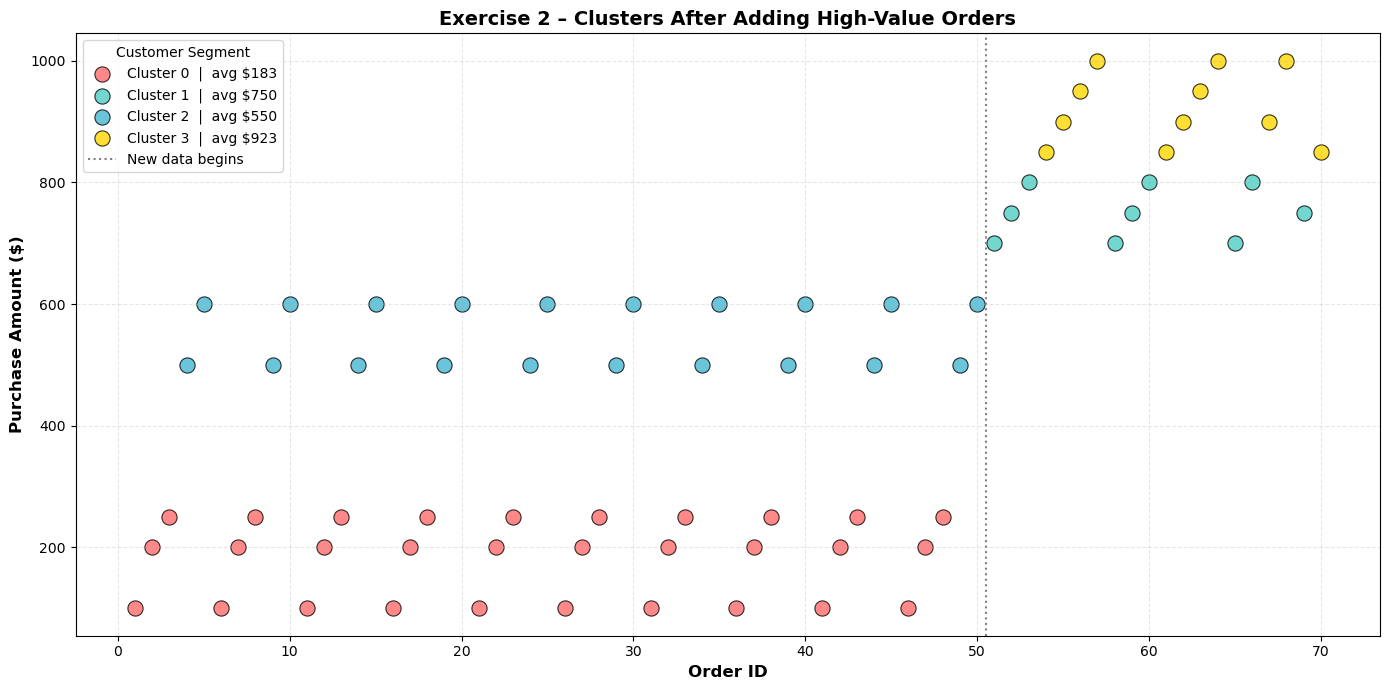

In [101]:
# Exercise 2 – Step C: Scatter plot for expanded dataset
colors_ex2 = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFD700']

plt.figure(figsize=(14, 7))

for cluster_num in sorted(df_ex2['Cluster'].unique()):
    cdata = df_ex2[df_ex2['Cluster'] == cluster_num]
    avg   = cdata['Amount'].mean()
    plt.scatter(
        cdata['OrderID'], cdata['Amount'],
        c=colors_ex2[cluster_num],
        label=f'Cluster {cluster_num}  |  avg ${avg:.0f}',
        s=120, alpha=0.8, edgecolors='black', linewidth=0.8
    )

plt.axvline(x=50.5, color='gray', linestyle=':', linewidth=1.5, label='New data begins')
plt.xlabel('Order ID', fontsize=12, fontweight='bold')
plt.ylabel('Purchase Amount ($)', fontsize=12, fontweight='bold')
plt.title('Exercise 2 – Clusters After Adding High-Value Orders', fontsize=14, fontweight='bold')
plt.legend(title='Customer Segment', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


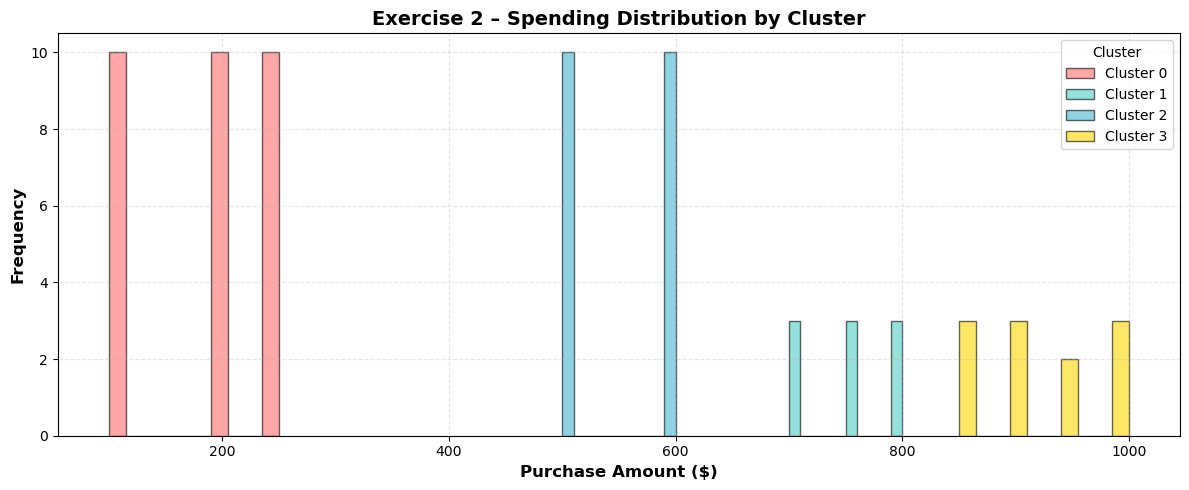

Adding extreme values (700-1000) pulled the high cluster center upward,
creating a new VIP segment that did not exist before.


In [102]:
# Exercise 2 – Step D: Distribution histogram coloured by cluster
plt.figure(figsize=(12, 5))

for cluster_num in sorted(df_ex2['Cluster'].unique()):
    cdata = df_ex2[df_ex2['Cluster'] == cluster_num]['Amount']
    plt.hist(cdata, bins=10, alpha=0.6,
             color=colors_ex2[cluster_num],
             label=f'Cluster {cluster_num}',
             edgecolor='black')

plt.xlabel('Purchase Amount ($)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Exercise 2 – Spending Distribution by Cluster', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("Adding extreme values (700-1000) pulled the high cluster center upward,")
print("creating a new VIP segment that did not exist before.")


### 🔍 Exercise 2 – What did we learn?

Adding very high amounts (\$700–\$1,000) **shifts cluster centers** and creates a brand-new top segment.

| Scenario | Highest Cluster Center |
|----------|----------------------|
| Original 50 orders | ~\$550 |
| Expanded 70 orders | ~\$870+ |

> **Business insight:** Always re-run clustering when you collect new data.  
> New customer types can appear and old segments can split or merge!


---
## ✏️ Exercise 3: Two-Feature Clustering (Amount + Category)

**Goal:** Cluster using **both** spending amount AND product category.

We encode the category as a number:
- Electronics → 1
- Clothing → 2
- Home → 3

K-Means will now group customers based on **what they buy AND how much they spend**.
This creates richer, more realistic customer profiles!


In [103]:
# Exercise 3 – Step A: Encode Category as a number
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

order_ids  = list(range(1, 51))
amounts    = [100, 200, 250, 500, 600] * 10
categories = ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing'] * 10

df_ex3 = pd.DataFrame({'OrderID': order_ids, 'Amount': amounts, 'Category': categories})

category_map = {'Electronics': 1, 'Clothing': 2, 'Home': 3}
df_ex3['Category_Num'] = df_ex3['Category'].map(category_map)

print("Category encoding:")
print(df_ex3[['Category', 'Category_Num']].drop_duplicates().to_string(index=False))
print()
print(df_ex3[['OrderID', 'Amount', 'Category', 'Category_Num']].head(10).to_string(index=False))


Category encoding:
   Category  Category_Num
Electronics             1
   Clothing             2
       Home             3

 OrderID  Amount    Category  Category_Num
       1     100 Electronics             1
       2     200    Clothing             2
       3     250 Electronics             1
       4     500        Home             3
       5     600    Clothing             2
       6     100 Electronics             1
       7     200    Clothing             2
       8     250 Electronics             1
       9     500        Home             3
      10     600    Clothing             2


In [104]:
# Exercise 3 – Step B: Scale the features
# IMPORTANT: Amount ranges 100-600 and Category_Num ranges 1-3.
# Without scaling, Amount dominates because its range is much larger.
# StandardScaler fixes this by centering and normalising each feature.

scaler = StandardScaler()
X_ex3  = scaler.fit_transform(df_ex3[['Amount', 'Category_Num']])

print("Scaled features (first 10 rows):")
print("  Amount_scaled   | Category_scaled")
print("-" * 36)
for row in X_ex3[:10]:
    print(f"  {row[0]:+.3f}         | {row[1]:+.3f}")


Scaled features (first 10 rows):
  Amount_scaled   | Category_scaled
------------------------------------
  -1.219         | -1.069
  -0.689         | +0.267
  -0.424         | -1.069
  +0.901         | +1.604
  +1.431         | +0.267
  -1.219         | -1.069
  -0.689         | +0.267
  -0.424         | -1.069
  +0.901         | +1.604
  +1.431         | +0.267


In [105]:
# Exercise 3 – Step C: Cluster with 2 features (k=4)
kmeans_ex3 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ex3['Cluster'] = kmeans_ex3.fit_predict(X_ex3)

print("Two-feature clustering complete!")
print()
print("Cluster summary:")
print("=" * 55)
for c in sorted(df_ex3['Cluster'].unique()):
    cdata   = df_ex3[df_ex3['Cluster'] == c]
    avg_amt = cdata['Amount'].mean()
    top_cat = cdata['Category'].value_counts().idxmax()
    count   = len(cdata)
    print(f"  Cluster {c}: {count} orders | avg ${avg_amt:.0f} | top category: {top_cat}")


Two-feature clustering complete!

Cluster summary:
  Cluster 0: 10 orders | avg $500 | top category: Home
  Cluster 1: 20 orders | avg $175 | top category: Electronics
  Cluster 2: 10 orders | avg $600 | top category: Clothing
  Cluster 3: 10 orders | avg $200 | top category: Clothing


c:\Users\iqras\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


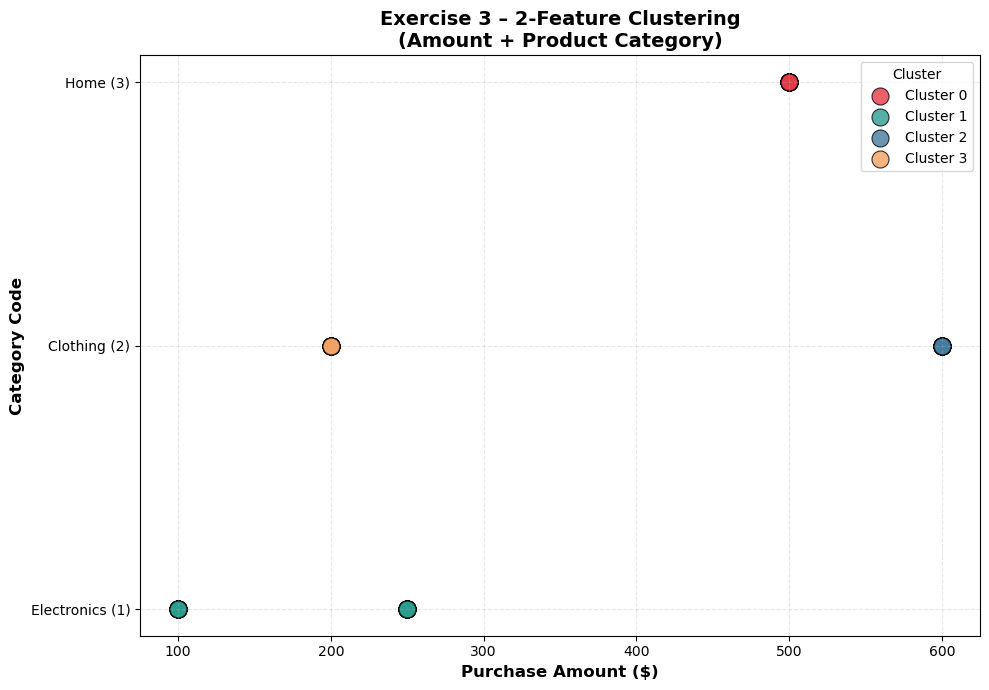

In [106]:
# Exercise 3 – Step D: 2D scatter — Amount vs Category_Num, coloured by cluster
colors_ex3 = ['#E63946', '#2A9D8F', '#457B9D', '#F4A261']

plt.figure(figsize=(10, 7))

for cluster_num in sorted(df_ex3['Cluster'].unique()):
    cdata = df_ex3[df_ex3['Cluster'] == cluster_num]
    plt.scatter(
        cdata['Amount'], cdata['Category_Num'],
        c=colors_ex3[cluster_num],
        label=f'Cluster {cluster_num}',
        s=150, alpha=0.8, edgecolors='black', linewidth=0.8
    )

plt.xlabel('Purchase Amount ($)', fontsize=12, fontweight='bold')
plt.ylabel('Category Code', fontsize=12, fontweight='bold')
plt.title('Exercise 3 – 2-Feature Clustering\n(Amount + Product Category)',
          fontsize=14, fontweight='bold')
plt.yticks([1, 2, 3], ['Electronics (1)', 'Clothing (2)', 'Home (3)'])
plt.legend(title='Cluster', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


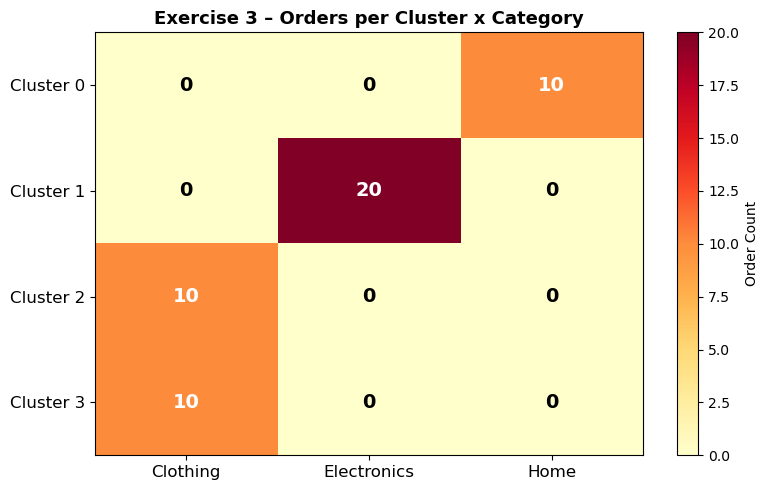

The heatmap shows which product categories dominate each cluster!


In [107]:
# Exercise 3 – Step E: Heatmap — cluster vs. category

pivot = df_ex3.groupby(['Cluster', 'Category']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=12)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'Cluster {i}' for i in pivot.index], fontsize=12)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, pivot.values[i, j], ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if pivot.values[i, j] > 5 else 'black')

plt.colorbar(im, label='Order Count')
ax.set_title('Exercise 3 – Orders per Cluster x Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("The heatmap shows which product categories dominate each cluster!")


In [108]:
# Exercise 3 – Step F: Rich customer profile report
print("\n" + "=" * 70)
print("CUSTOMER PROFILE REPORT — TWO-FEATURE CLUSTERING")
print("=" * 70)

icons = {0: 'Segment A', 1: 'Segment B', 2: 'Segment C', 3: 'Segment D'}

for c in sorted(df_ex3['Cluster'].unique()):
    cdata  = df_ex3[df_ex3['Cluster'] == c]
    avg_a  = cdata['Amount'].mean()
    top_c  = cdata['Category'].value_counts().idxmax()
    count  = len(cdata)
    cats   = cdata['Category'].value_counts().to_dict()

    print(f"\n[{icons[c]}] Cluster {c}")
    print(f"   Orders       : {count}")
    print(f"   Avg Spending : ${avg_a:.2f}")
    print(f"   Top Category : {top_c}")
    print(f"   Category mix : {cats}")

    if avg_a < 200:
        tip = 'Send budget deals & coupons for their favourite category.'
    elif avg_a < 400:
        tip = 'Recommend bundles and mid-range upgrades.'
    else:
        tip = 'Offer premium memberships, early access, and loyalty rewards.'
    print(f"   Marketing Tip: {tip}")



CUSTOMER PROFILE REPORT — TWO-FEATURE CLUSTERING

[Segment A] Cluster 0
   Orders       : 10
   Avg Spending : $500.00
   Top Category : Home
   Category mix : {'Home': 10}
   Marketing Tip: Offer premium memberships, early access, and loyalty rewards.

[Segment B] Cluster 1
   Orders       : 20
   Avg Spending : $175.00
   Top Category : Electronics
   Category mix : {'Electronics': 20}
   Marketing Tip: Send budget deals & coupons for their favourite category.

[Segment C] Cluster 2
   Orders       : 10
   Avg Spending : $600.00
   Top Category : Clothing
   Category mix : {'Clothing': 10}
   Marketing Tip: Offer premium memberships, early access, and loyalty rewards.

[Segment D] Cluster 3
   Orders       : 10
   Avg Spending : $200.00
   Top Category : Clothing
   Category mix : {'Clothing': 10}
   Marketing Tip: Recommend bundles and mid-range upgrades.


### 🔍 Exercise 3 – What did we learn?

Using **two features** gives richer customer profiles than one feature alone.

| Feature set | What we can learn |
|-------------|------------------|
| Amount only | Low / Medium / High spender |
| Amount + Category | *Which type* of products each segment prefers |

> **Business insight:** Companies like Amazon combine **dozens** of features  
> (spending, frequency, categories, browsing history …) for highly personalised segments!

---
## 🏆 All 3 Exercises Complete!
